<center><h1>Viusualisations and Analysis of the Results</h1></center>
<center><h1>Acceleration of CFD using CUDA</h1></center>

## imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import seaborn as sns

## parameters

In [2]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 18

## path

a path to the folder where generated graphs are stored, should be adjusted by the user

In [ ]:
PATH = "C:figures\\" 

## helper function

In [4]:
def locate(arr, target):
    return np.abs(arr - target).argmin()

## quadrant

In [5]:
dim_q = 400

### cpu

In [6]:
q_cpu_pre = pd.read_csv("xy/quadrant-cpu-pre.csv", sep=",", header=None, dtype=float)
q_cpu_pre = q_cpu_pre.dropna(axis=1)
q_cpu_pre.shape

(368, 160000)

In [7]:
q_cpu_time = pd.read_csv("xy/quadrant-cpu-time.csv", sep=",", header=None, dtype=float)
q_cpu_time = q_cpu_time.dropna(axis=1)
q_cpu_time = q_cpu_time.to_numpy()[0]

In [8]:
quadrants_pressure_cpu = []

for i in range(q_cpu_pre.shape[0]):
    quadrants_pressure_cpu.append(pd.DataFrame(q_cpu_pre.iloc[i, :dim_q*dim_q].values.reshape(dim_q, dim_q)))

In [9]:
q_index_cpu_end = locate(q_cpu_time, (len(quadrants_pressure_cpu)))

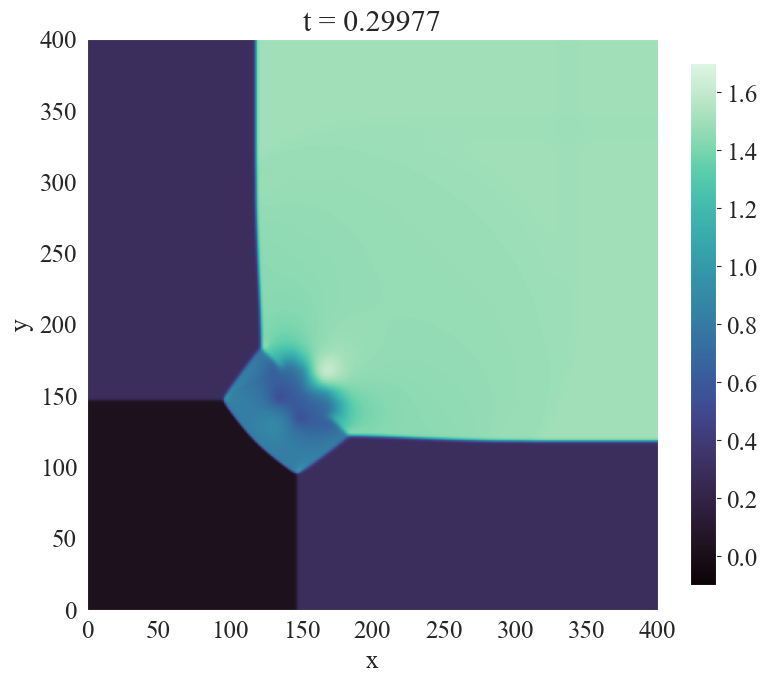

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
        
im = ax.imshow(quadrants_pressure_cpu[q_index_cpu_end], cmap="mako", vmin=-0.1, vmax=1.7)
fig.colorbar(im, ax=ax, fraction=0.07, pad=0.05, shrink=0.7, location="right")
fig.tight_layout()

ax.invert_yaxis() 
ax.set_xticks(range(0, dim_q + 1, 50))
ax.set_yticks(range(0, dim_q + 1, 50))

plt.grid(False)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"t = {q_cpu_time[q_index_cpu_end]}")
plt.tight_layout()
plt.savefig(PATH + "quad-cpu-end.png")
plt.show()

### cuda

In [11]:
q_cuda_pre = pd.read_csv("xy/quadrant-cuda-pre.csv", sep=",", header=None, dtype=float)
q_cuda_pre = q_cuda_pre.dropna(axis=1)
q_cuda_pre.shape

(369, 160000)

In [12]:
q_cuda_time = pd.read_csv("xy/quadrant-cuda-time.csv", sep=",", header=None, dtype=float)
q_cuda_time = q_cuda_time.dropna(axis=1)
q_cuda_time = q_cuda_time.to_numpy()[0]

In [13]:
quadrants_pressure_cuda = []

for i in range(q_cuda_pre.shape[0]):
    quadrants_pressure_cuda.append(pd.DataFrame(q_cuda_pre.iloc[i, :dim_q*dim_q].values.reshape(dim_q, dim_q)))

In [14]:
q_index_cuda_end = locate(q_cuda_time, (len(quadrants_pressure_cuda)))

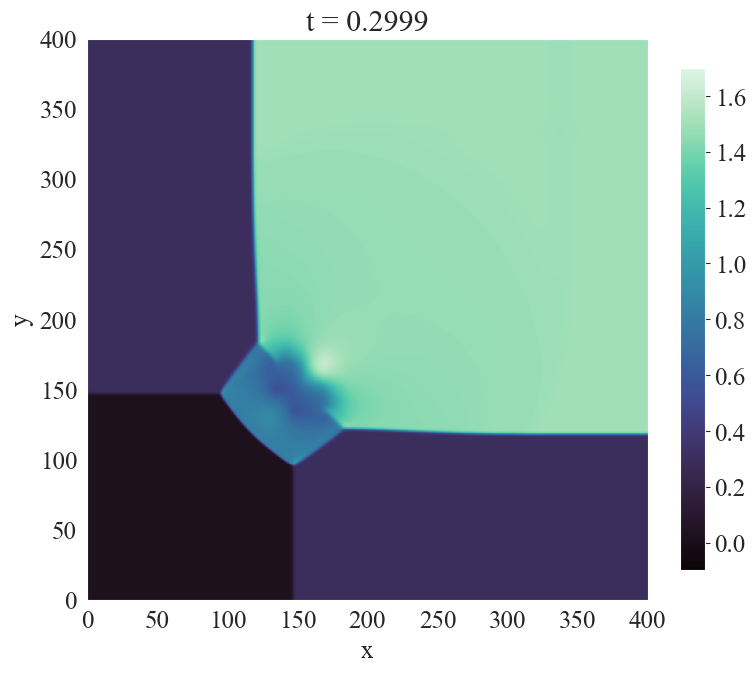

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
        
im = ax.imshow(quadrants_pressure_cuda[q_index_cuda_end], cmap="mako", vmin=-0.1, vmax=1.7)
fig.colorbar(im, ax=ax, fraction=0.07, pad=0.05, shrink=0.7, location="right")

ax.invert_yaxis() 
ax.set_xticks(range(0, dim_q + 1, 50))
ax.set_yticks(range(0, dim_q + 1, 50))

plt.grid(False)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"t = {q_cuda_time[q_index_cuda_end]}")
plt.tight_layout()
plt.savefig(PATH + "quad-cuda-end.png")
plt.show()

### norm difference quadrants

In [16]:
q_norm = np.linalg.norm(quadrants_pressure_cpu[q_index_cpu_end] - quadrants_pressure_cuda[q_index_cuda_end])

print(f"l2-norm of the difference for the final timestep is: {q_norm}")

l2-norm of the difference for the final timestep is: 1.7525093132128455


## bubble

In [17]:
dim_x = 500
dim_y = 200

### cpu

In [18]:
b_cpu_den = pd.read_csv("xy/bubble-cpu-den.csv", sep=",", header=None, dtype=float)
b_cpu_den = b_cpu_den.dropna(axis=1)
b_cpu_den.shape

(3134, 100000)

In [19]:
b_cpu_time = pd.read_csv("xy/bubble-cpu-time.csv", sep=",", header=None, dtype=float)
b_cpu_time = b_cpu_time.dropna(axis=1)
b_cpu_time = b_cpu_time.to_numpy()[0]

In [20]:
bubbles_pressure_cpu = []

for i in range(b_cpu_den.shape[0]):
    bubbles_pressure_cpu.append(pd.DataFrame(b_cpu_den.iloc[i, :dim_x*dim_y].values.reshape(dim_y, dim_x)))

In [21]:
b_index_cpu_end = locate(b_cpu_time, (len(bubbles_pressure_cpu)))

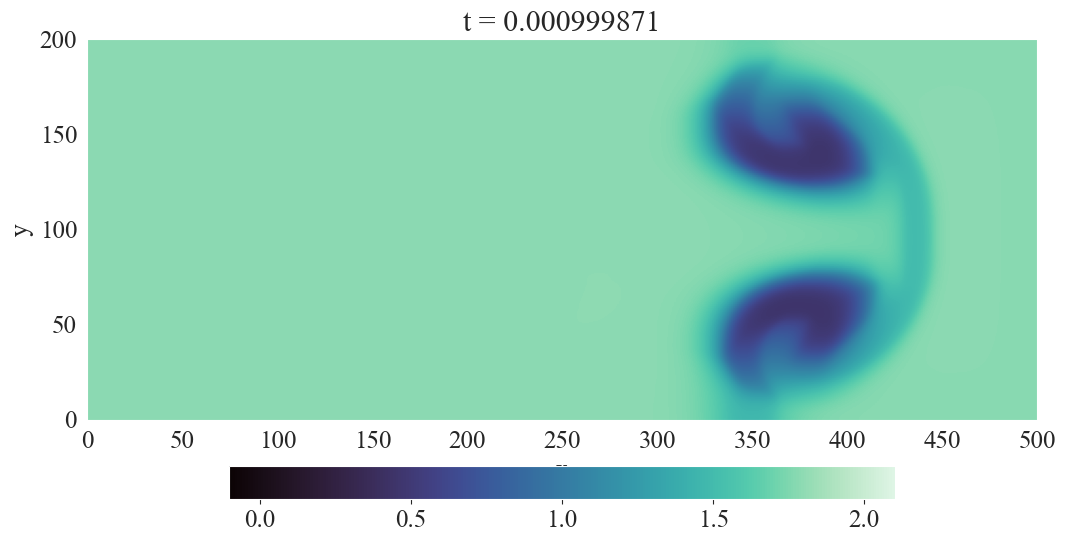

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
        
im = ax.imshow(bubbles_pressure_cpu[b_index_cpu_end], cmap="mako", vmin=-0.1, vmax=2.1)
fig.colorbar(im, ax=ax, fraction=0.07, pad=0.09, shrink=0.7, location="bottom")

ax.invert_yaxis() 
ax.set_xticks(range(0, dim_x + 1, 50))
ax.set_yticks(range(0, dim_y + 1, 50))

plt.grid(False)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"t = {b_cpu_time[b_index_cpu_end]}")
plt.tight_layout()
plt.savefig(PATH + "bubble-cpu-end.png")
plt.show()

### cuda

In [23]:
b_cuda_den = pd.read_csv("xy/bubble-cuda-den.csv", sep=",", header=None)
b_cuda_den = b_cuda_den.dropna(axis=1)
b_cuda_den.shape

(3135, 100000)

In [24]:
b_cuda_time = pd.read_csv("xy/bubble-cuda-time.csv", sep=",", header=None)
b_cuda_time = b_cuda_time.dropna(axis=1)
b_cuda_time = b_cuda_time.to_numpy()[0]

In [25]:
bubbles_pressure_cuda = []

dim_x = 500
dim_y = 200

for i in range(b_cuda_den.shape[0]):
    bubbles_pressure_cuda.append(pd.DataFrame(b_cuda_den.iloc[i, :dim_x*dim_y].values.reshape(dim_y, dim_x)))

In [26]:
b_index_cuda_end = locate(b_cuda_time, (len(bubbles_pressure_cuda)))

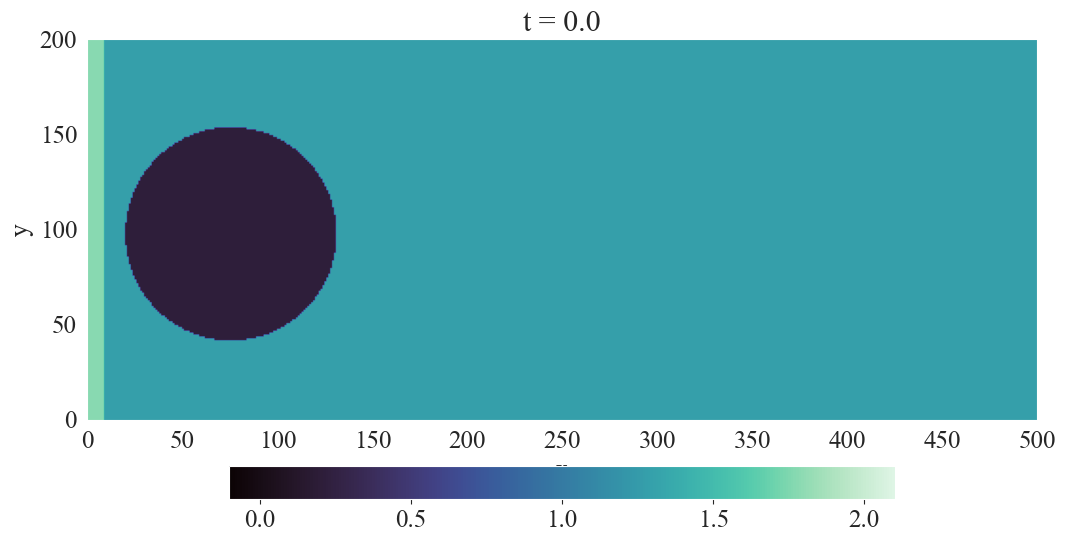

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))
        
im = ax.imshow(bubbles_pressure_cuda[0], cmap='mako', vmin=-0.1, vmax=2.1)
fig.colorbar(im, ax=ax, fraction=0.07, pad=0.09, shrink=0.7, location="bottom")
fig.tight_layout()

ax.invert_yaxis() 
ax.set_xticks(range(0, dim_x + 1, 50))
ax.set_yticks(range(0, dim_y + 1, 50))

plt.grid(False)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"t = {b_cuda_time[0]}")
plt.tight_layout()
plt.savefig(PATH + "bubble-start.png")
plt.show()

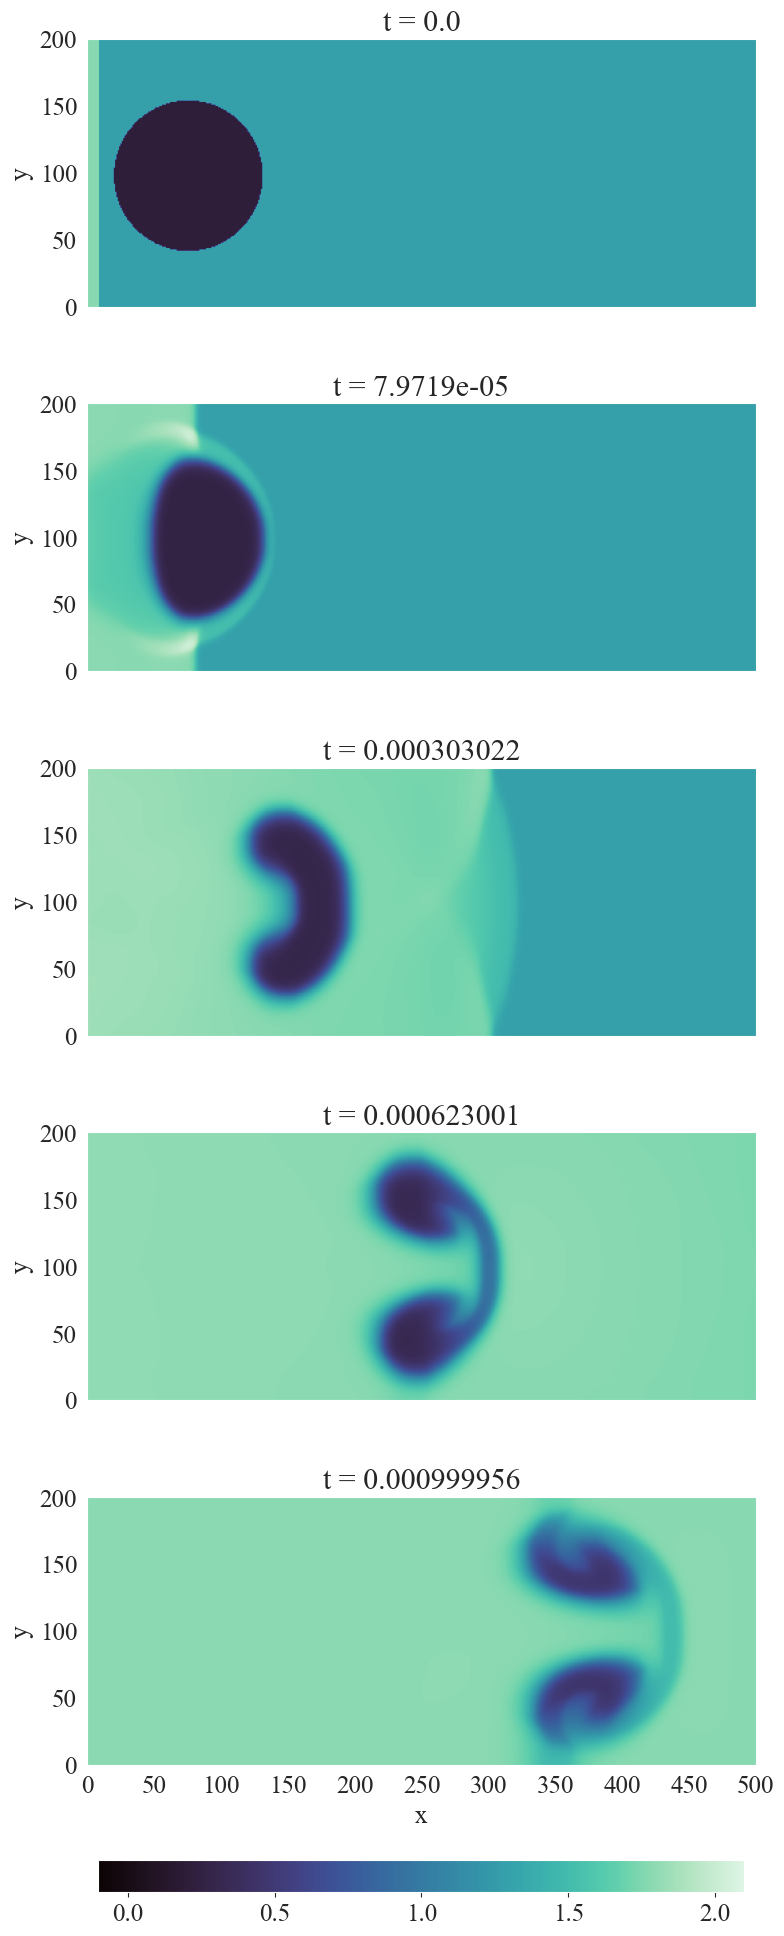

In [28]:
frames = [0, 250, 1000, 2000, locate(b_cuda_time, len(bubbles_pressure_cuda))]

fig, ax = plt.subplots(5, 1, figsize=(8, 20), sharex=True)

for i in range(5):
    im = ax[i].imshow(bubbles_pressure_cuda[frames[i]], cmap="mako", vmin=-0.1, vmax=2.1)
    
    ax[i].invert_yaxis()
    ax[i].set_aspect(1)  
    ax[i].set_ylabel("y")
    ax[i].set_yticks(range(0, dim_y + 1, 50))

    ax[i].set_title(f"t = {b_cuda_time[frames[i]]}")
    ax[i].grid(False)


plt.tight_layout()

cbar = fig.colorbar(im, ax=ax.ravel().tolist(), orientation="horizontal", fraction=0.017, pad=0.05)

plt.xlabel("x")
plt.xticks((range(0, dim_x + 1, 50)))
plt.grid(False)
plt.savefig(PATH + "bubbles-cuda.png")
plt.show()

### norm difference bubbles

In [29]:
b_norm = np.linalg.norm(bubbles_pressure_cpu[b_index_cpu_end] - bubbles_pressure_cuda[b_index_cuda_end])

print(f"l2-norm of the difference for the final timestep is: {b_norm}")

l2-norm of the difference for the final timestep is: 3.5786760005339966
